In [2]:
# %pip install --user zernike

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from zernike import RZern

j, n, m: 1 0 1
j, n, m: 2 1 -1
j, n, m: 3 1 -2
j, n, m: 4 2 1
j, n, m: 5 2 2
j, n, m: 6 2 3
j, n, m: 7 3 -1
j, n, m: 8 3 -2
j, n, m: 9 3 -3
j, n, m: 10 3 -4
j, n, m: 11 4 1
j, n, m: 12 4 2
j, n, m: 13 4 3
j, n, m: 14 4 4
j, n, m: 15 4 5
j, n, m: 16 5 -1
j, n, m: 17 5 -2


/tmp/ipykernel_11634/3744093568.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(x, y, Z, cmap='RdBu_r', shading='auto', vmin=-1, vmax=1)


j, n, m: 18 5 -3
j, n, m: 19 5 -4
j, n, m: 20 5 -5
j, n, m: 21 5 -6


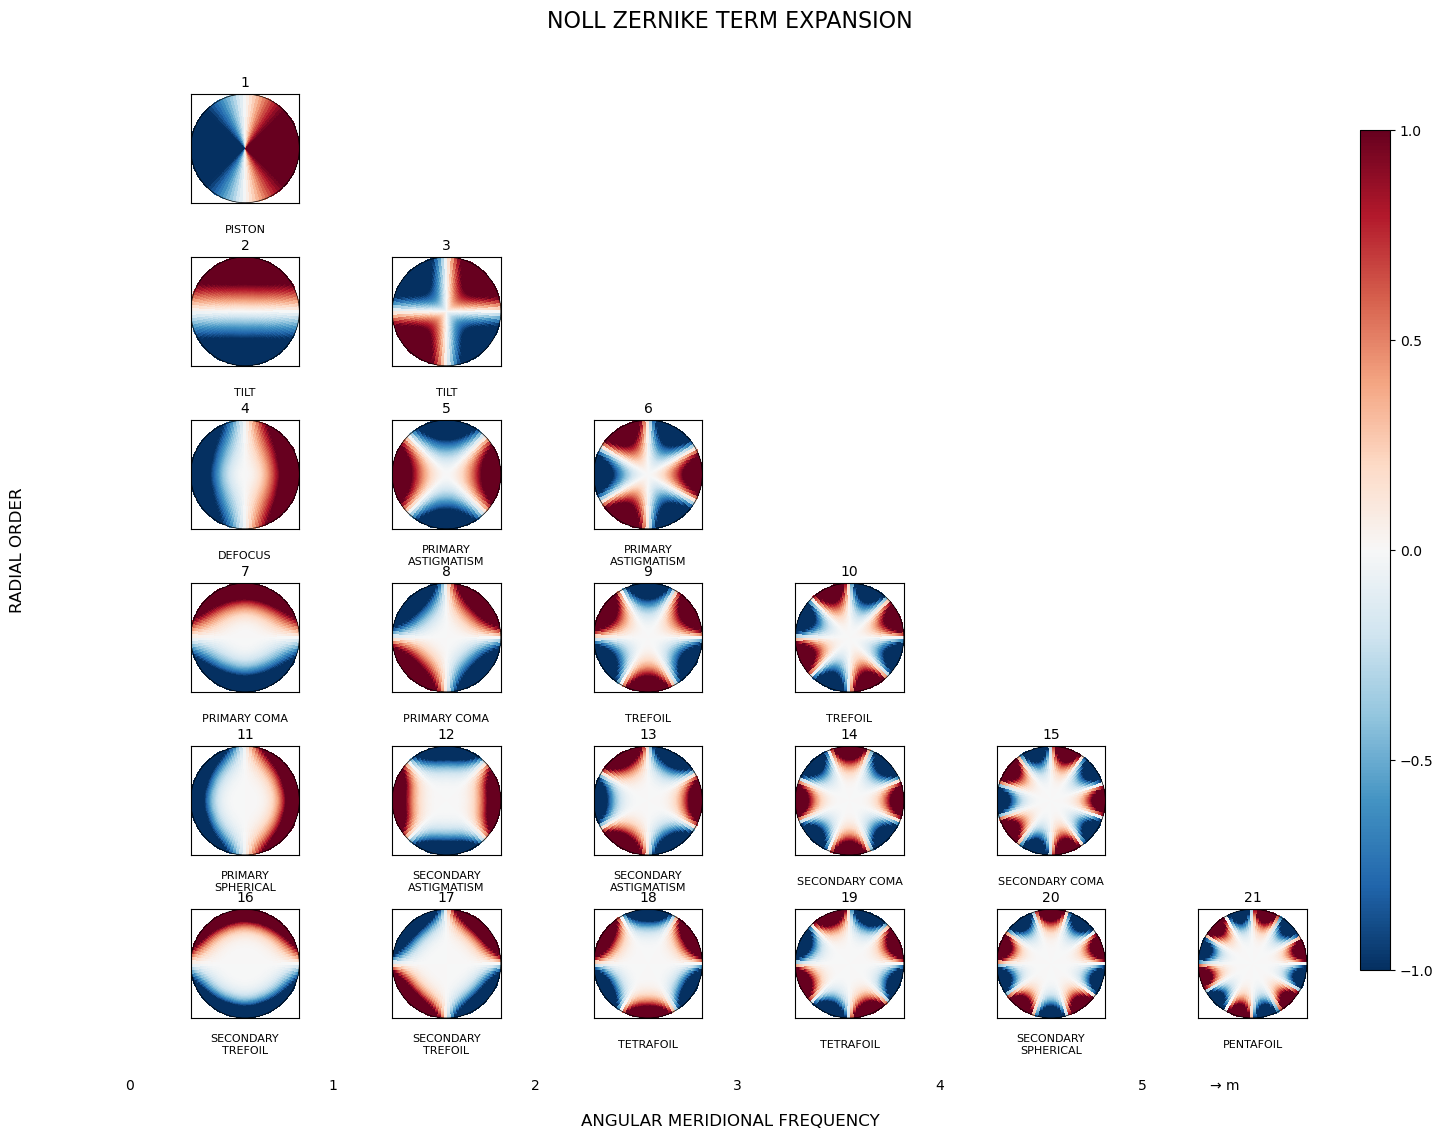

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def zernike_polynomial(n, m, rho, theta):
    if m == 0:
        return np.sqrt(n + 1) * rho**n
    elif m > 0:
        return np.sqrt(2 * (n + 1)) * rho**n * np.cos(m * theta)
    else:
        return np.sqrt(2 * (n + 1)) * rho**n * np.sin(-m * theta)

def noll_to_zernike(j):
    n = int(np.floor((np.sqrt(8*j-7)-1)/2))
    m = j - (n*(n+1))//2
    if m > 0 and n % 2 == 1:  # odd n
        m = -m
    elif m > 0 and n % 2 == 0:  # even n
        m = m
    return n, m

def plot_zernike(ax, j):
    n, m = noll_to_zernike(j)
    print("j, n, m:", j, n, m)
    r = np.linspace(0, 1, 100)
    theta = np.linspace(0, 2*np.pi, 100)
    r, theta = np.meshgrid(r, theta)
    Z = zernike_polynomial(n, m, r, theta)
    
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    im = ax.pcolormesh(x, y, Z, cmap='RdBu_r', shading='auto', vmin=-1, vmax=1)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    circle = plt.Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=0.5)
    ax.add_artist(circle)
    return im

def main():
    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(6, 6, hspace=0.5, wspace=0.3)

    titles = ['PISTON', 'TILT', 'TILT', 'DEFOCUS', 'PRIMARY\nASTIGMATISM', 'PRIMARY\nASTIGMATISM',
              'PRIMARY COMA', 'PRIMARY COMA', 'TREFOIL', 'TREFOIL', 'PRIMARY\nSPHERICAL', 'SECONDARY\nASTIGMATISM',
              'SECONDARY\nASTIGMATISM', 'SECONDARY COMA', 'SECONDARY COMA', 'SECONDARY\nTREFOIL', 'SECONDARY\nTREFOIL', 'TETRAFOIL',
              'TETRAFOIL', 'SECONDARY\nSPHERICAL', 'PENTAFOIL', 'PENTAFOIL']

    plot_positions = [
        (0, 0),
        (1, 0), (1, 1),
        (2, 0),
        (2, 1), (2, 2),
        (3, 0), (3, 1),
        (3, 2), (3, 3),
        (4, 0),
        (4, 1), (4, 2),
        (4, 3), (4, 4),
        (5, 0), (5, 1),
        (5, 2), (5, 3),
        (5, 4),
        (5, 5)
    ]

    for idx, pos in enumerate(plot_positions, start=1):
        ax = fig.add_subplot(gs[pos[0], pos[1]])
        im = plot_zernike(ax, idx)
        ax.set_title(f'{idx}', fontsize=10, pad=5)
        if titles[idx-1]:
            ax.text(0.5, -0.25, titles[idx-1], ha='center', va='center', transform=ax.transAxes, fontsize=8)

    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

    # Add labels
    fig.text(0.5, 0.02, 'ANGULAR MERIDIONAL FREQUENCY', ha='center', fontsize=12)
    fig.text(0.02, 0.5, 'RADIAL ORDER', va='center', rotation='vertical', fontsize=12)

    # Add title
    fig.suptitle('NOLL ZERNIKE TERM EXPANSION', fontsize=16, y=0.95)

    # Add m labels
    for i in range(6):
        fig.text(0.1 + i*0.135, 0.05, f'{i}', ha='center', fontsize=10)

    # Add arrow
    fig.text(0.82, 0.05, '→ m', ha='left', fontsize=10)

    plt.show()

if __name__ == "__main__":
    main()

/tmp/ipykernel_12758/4264479003.py:18: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(x, y, Z, cmap='RdBu_r', shading='auto', vmin=-1, vmax=1)


IndexError: index 21 is out of bounds for axis 0 with size 21

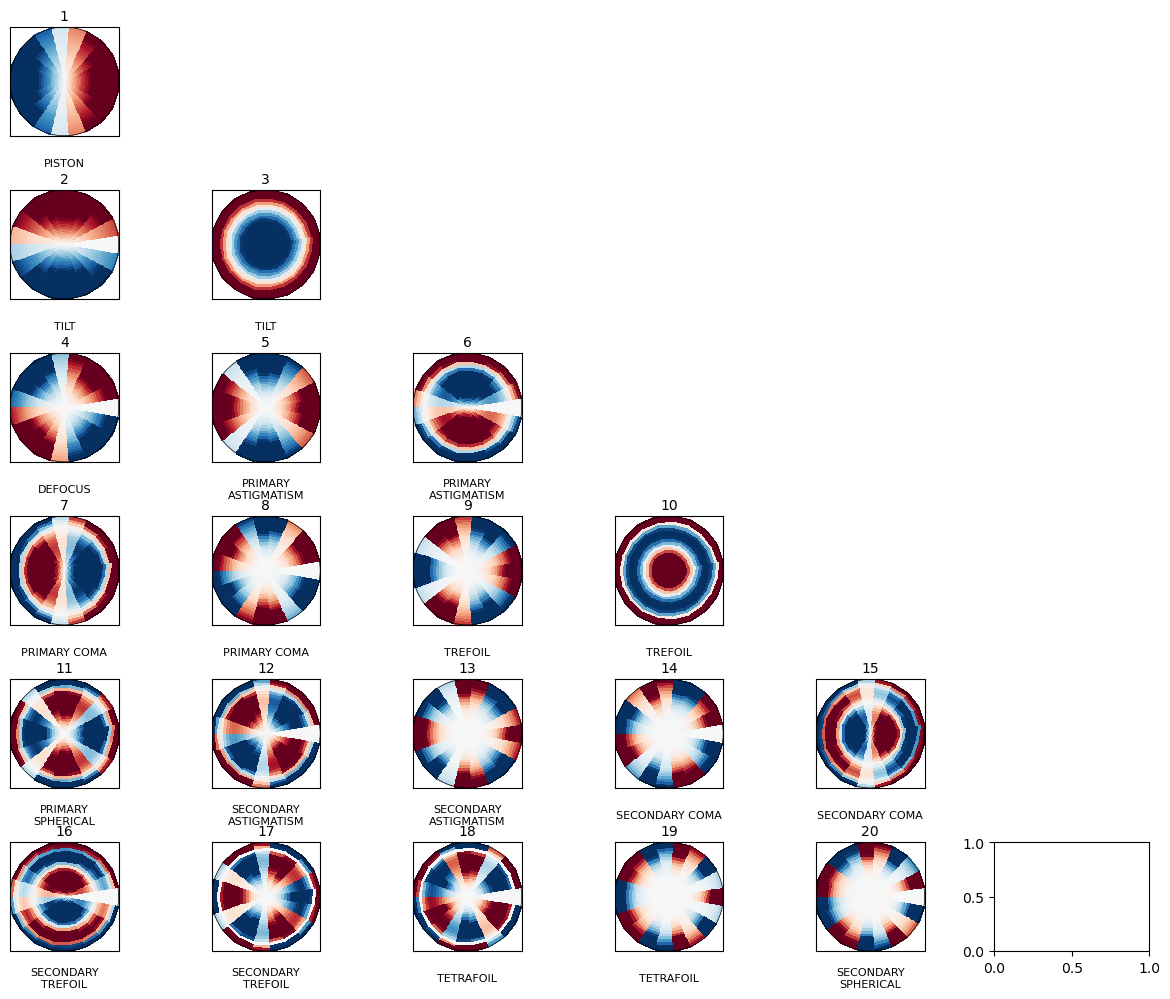

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

def plot_zernike(ax, j, zern):
    # Calculate Zernike polynomial in patches
    patch_size = 20
    r = np.linspace(0, 1, patch_size)
    theta = np.linspace(0, 2*np.pi, patch_size)
    rho, theta = np.meshgrid(r, theta)
    
    zern.make_pol_grid(rho, theta)
    Z = zern.Zk(j, rho, theta)
    
    x = rho * np.cos(theta)
    y = rho * np.sin(theta)
    
    im = ax.pcolormesh(x, y, Z, cmap='RdBu_r', shading='auto', vmin=-1, vmax=1)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    circle = plt.Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=0.5)
    ax.add_artist(circle)
    return im

def main():
    fig = plt.figure(figsize=(15, 12))
    gs = fig.add_gridspec(6, 6, hspace=0.5, wspace=0.3)

    titles = ['PISTON', 'TILT', 'TILT', 'DEFOCUS', 'PRIMARY\nASTIGMATISM', 'PRIMARY\nASTIGMATISM',
              'PRIMARY COMA', 'PRIMARY COMA', 'TREFOIL', 'TREFOIL', 'PRIMARY\nSPHERICAL', 'SECONDARY\nASTIGMATISM',
              'SECONDARY\nASTIGMATISM', 'SECONDARY COMA', 'SECONDARY COMA', 'SECONDARY\nTREFOIL', 'SECONDARY\nTREFOIL', 'TETRAFOIL',
              'TETRAFOIL', 'SECONDARY\nSPHERICAL', 'PENTAFOIL', 'PENTAFOIL']

    plot_positions = [
        (0, 0),
        (1, 0), (1, 1),
        (2, 0),
        (2, 1), (2, 2),
        (3, 0), (3, 1),
        (3, 2), (3, 3),
        (4, 0),
        (4, 1), (4, 2),
        (4, 3), (4, 4),
        (5, 0), (5, 1),
        (5, 2), (5, 3),
        (5, 4),
        (5, 5)
    ]

    # Initialize RZern object
    zern = RZern(5)

    for idx, pos in enumerate(plot_positions, start=1):
        ax = fig.add_subplot(gs[pos[0], pos[1]])
        im = plot_zernike(ax, idx, zern)
        ax.set_title(f'{idx}', fontsize=10, pad=5)
        if titles[idx-1]:
            ax.text(0.5, -0.25, titles[idx-1], ha='center', va='center', transform=ax.transAxes, fontsize=8)

    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

    # Add labels
    fig.text(0.5, 0.02, 'ANGULAR MERIDIONAL FREQUENCY', ha='center', fontsize=12)
    fig.text(0.02, 0.5, 'RADIAL ORDER', va='center', rotation='vertical', fontsize=12)

    # Add title
    fig.suptitle('NOLL ZERNIKE TERM EXPANSION', fontsize=16, y=0.95)

    # Add m labels
    for i in range(6):
        fig.text(0.1 + i*0.135, 0.05, f'{i}', ha='center', fontsize=10)

    # Add arrow
    fig.text(0.82, 0.05, '→ m', ha='left', fontsize=10)

    plt.show()

if __name__ == "__main__":
    main()

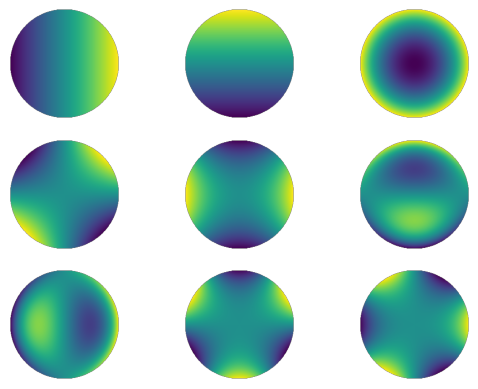

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

cart = RZern(6)
L, K = 200, 250
ddx = np.linspace(-1.0, 1.0, K)
ddy = np.linspace(-1.0, 1.0, L)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)

c = np.zeros(cart.nk)
plt.figure(1)
for i in range(1, 10):
    plt.subplot(3, 3, i)
    c *= 0.0
    c[i] = 1.0
    Phi = cart.eval_grid(c, matrix=True)
    plt.imshow(Phi, origin='lower', extent=(-1, 1, -1, 1))
    plt.axis('off')

plt.show()

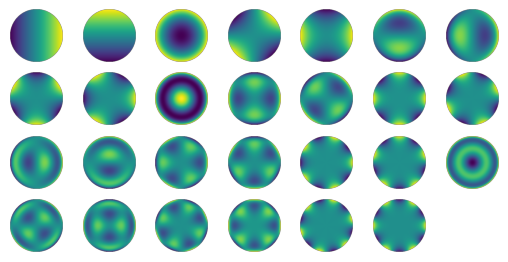

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

cart = RZern(6)
L, K = 200, 250
ddx = np.linspace(-1.0, 1.0, K)
ddy = np.linspace(-1.0, 1.0, L)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)

c = np.zeros(cart.nk)
plt.figure(1)
for i in range(1, 28):
    plt.subplot(6, 7, i)
    c *= 0.0
    c[i] = 1.0
    Phi = cart.eval_grid(c, matrix=True)
    plt.imshow(Phi, origin='lower', extent=(-1, 1, -1, 1))
    plt.axis('off')

plt.show()

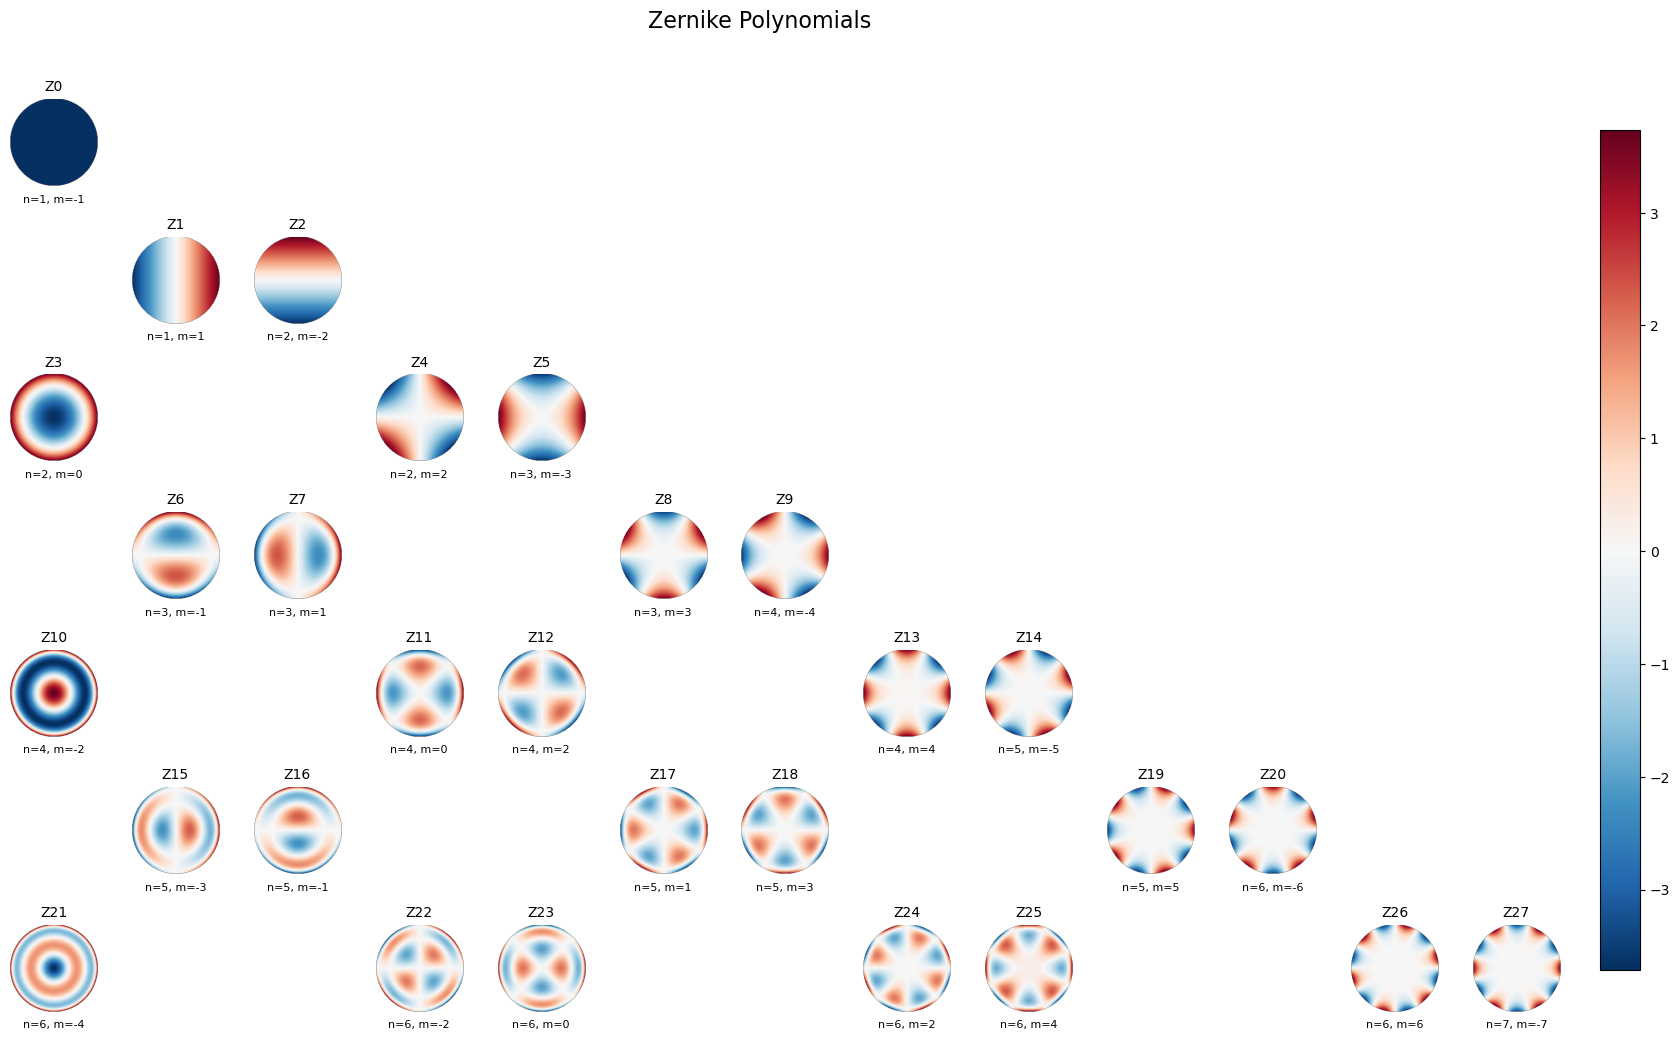

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

def noll_to_zernike(j):
    n = int(np.floor((np.sqrt(8*j+1)-1)/2))
    m = 2*j - n*(n+2)
    return n, m

cart = RZern(6)
L, K = 200, 250
ddx = np.linspace(-1.0, 1.0, K)
ddy = np.linspace(-1.0, 1.0, L)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)

c = np.zeros(cart.nk)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(7, 13, hspace=0.4, wspace=0.4)

plot_positions = [
    (0, 0),
           (1, 1), (1, 2),
    (2, 0),               (2, 3), (2, 4),
           (3, 1), (3, 2),               (3, 5), (3, 6),
    (4, 0),               (4, 3), (4, 4),               (4, 7), (4, 8),
           (5, 1), (5, 2),               (5, 5), (5, 6),               (5, 9), (5, 10),
    (6, 0),               (6, 3), (6, 4),               (6, 7), (6, 8),               (6, 11), (6, 12)
]

for i in range(28):
    ax = fig.add_subplot(gs[plot_positions[i]])
    c *= 0.0
    c[i] = 1.0
    Phi = cart.eval_grid(c, matrix=True)
    im = ax.imshow(Phi, origin='lower', extent=(-1, 1, -1, 1), cmap='RdBu_r')
    ax.set_title(f'Z{i}', fontsize=10)
    ax.axis('off')
    
    # Add n, m labels
    n, m = noll_to_zernike(i+1)  # i+1 because Noll indices start at 1
    ax.text(0.5, -0.15, f'n={n}, m={m}', ha='center', va='center', transform=ax.transAxes, fontsize=8)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)

# Add title
fig.suptitle('Zernike Polynomials', fontsize=16, y=0.95)

plt.show()

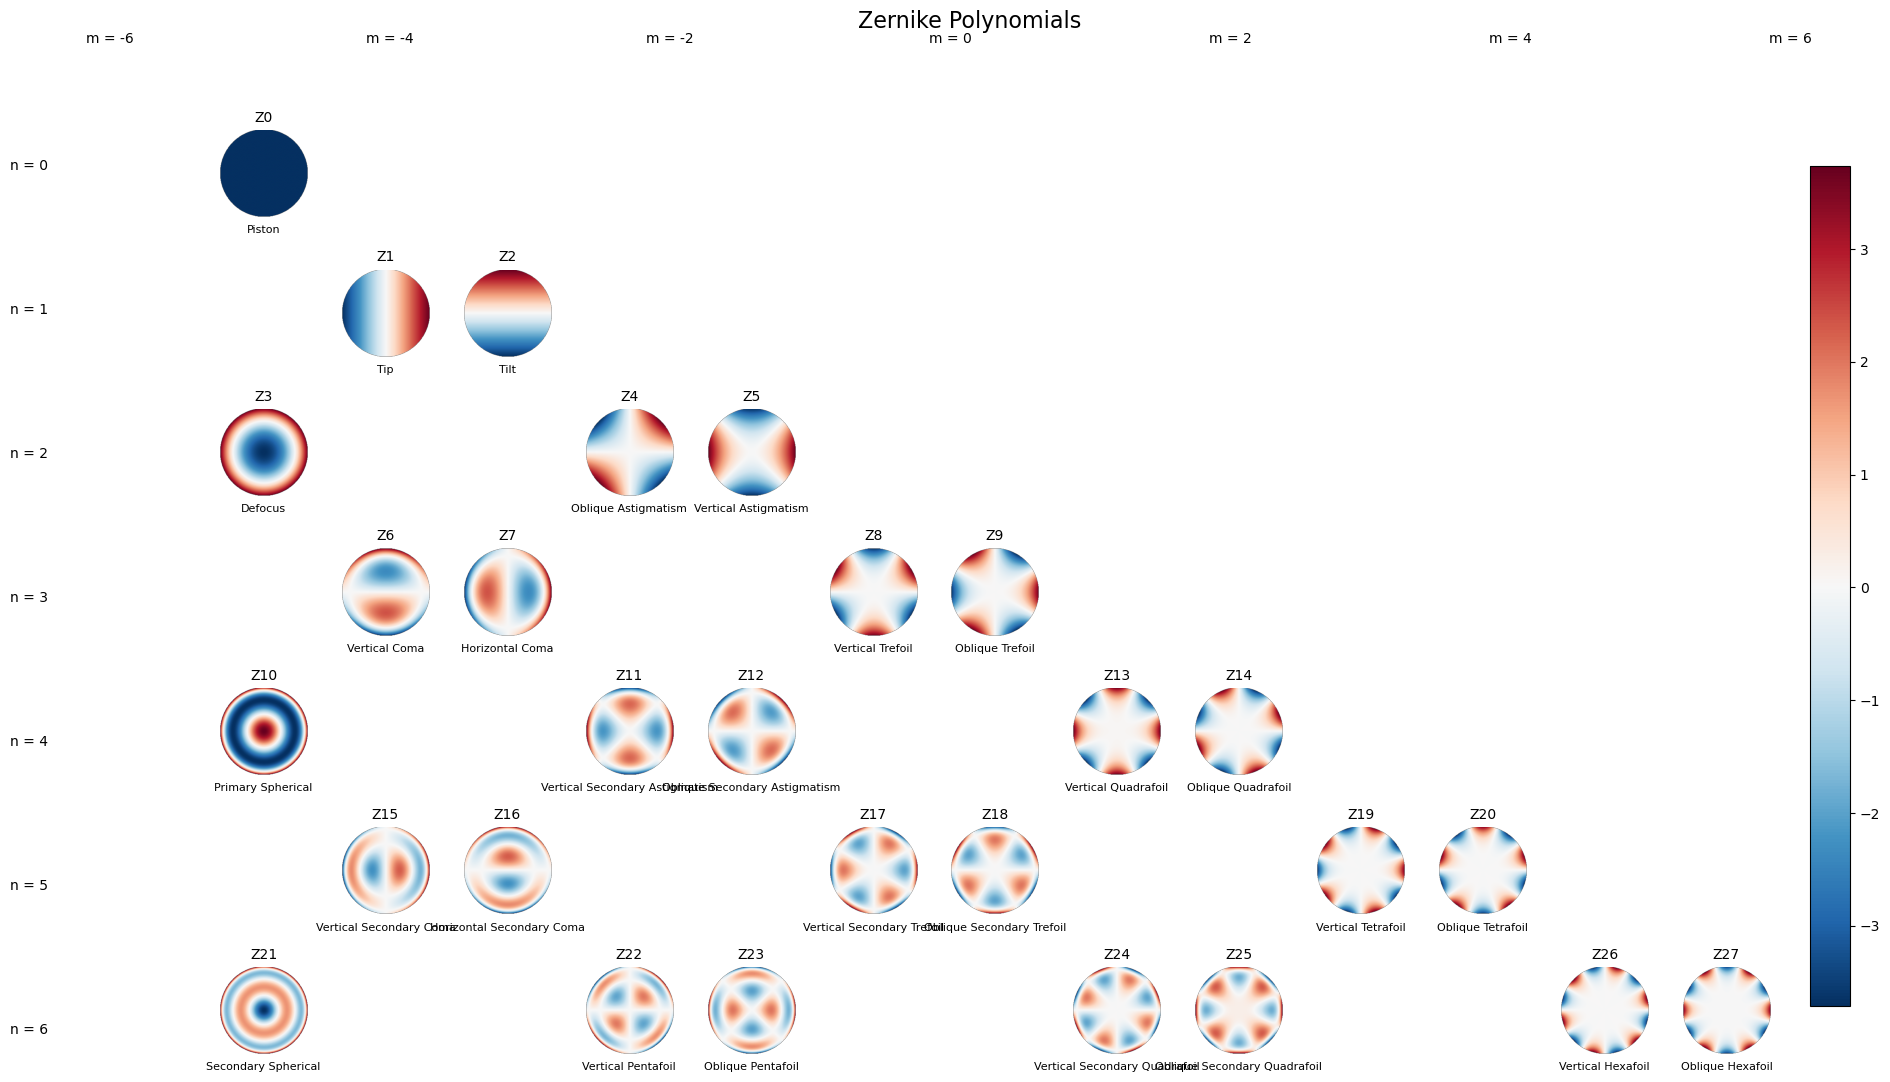

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

def noll_to_zernike(j):
    n = int(np.floor((np.sqrt(8*j+1)-1)/2))
    m = 2*j - n*(n+2)
    return n, m

cart = RZern(6)
L, K = 200, 250
ddx = np.linspace(-1.0, 1.0, K)
ddy = np.linspace(-1.0, 1.0, L)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)

c = np.zeros(cart.nk)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(7, 13, hspace=0.6, wspace=0.4)

plot_positions = [
    (0, 0),
           (1, 1), (1, 2),
    (2, 0),               (2, 3), (2, 4),
           (3, 1), (3, 2),               (3, 5), (3, 6),
    (4, 0),               (4, 3), (4, 4),               (4, 7), (4, 8),
           (5, 1), (5, 2),               (5, 5), (5, 6),               (5, 9), (5, 10),
    (6, 0),               (6, 3), (6, 4),               (6, 7), (6, 8),               (6, 11), (6, 12)
]

zernike_names = [
    "Piston", "Tip", "Tilt", "Defocus", "Oblique Astigmatism", "Vertical Astigmatism",
    "Vertical Coma", "Horizontal Coma", "Vertical Trefoil", "Oblique Trefoil", "Primary Spherical",
    "Vertical Secondary Astigmatism", "Oblique Secondary Astigmatism", "Vertical Quadrafoil",
    "Oblique Quadrafoil", "Vertical Secondary Coma", "Horizontal Secondary Coma",
    "Vertical Secondary Trefoil", "Oblique Secondary Trefoil", "Vertical Tetrafoil",
    "Oblique Tetrafoil", "Secondary Spherical", "Vertical Pentafoil", "Oblique Pentafoil",
    "Vertical Secondary Quadrafoil", "Oblique Secondary Quadrafoil", "Vertical Hexafoil", "Oblique Hexafoil"
]

for i in range(28):
    ax = fig.add_subplot(gs[plot_positions[i]])
    c *= 0.0
    c[i] = 1.0
    Phi = cart.eval_grid(c, matrix=True)
    im = ax.imshow(Phi, origin='lower', extent=(-1, 1, -1, 1), cmap='RdBu_r')
    ax.set_title(f'Z{i}', fontsize=10)
    ax.axis('off')
    
    # Add Zernike name labels
    ax.text(0.5, -0.15, zernike_names[i], ha='center', va='center', transform=ax.transAxes, fontsize=8, wrap=True)

# Add n, m labels along rows and columns
for i in range(7):
    fig.text(0.02, 0.85 - i*0.12, f'n = {i}', ha='left', va='center', fontsize=10)

for i in range(13):
    if i % 2 == 0:
        m = i - 6
        fig.text(0.07 + i*0.07, 0.95, f'm = {m}', ha='center', va='bottom', fontsize=10)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)

# Add title
fig.suptitle('Zernike Polynomials', fontsize=16, y=0.98)

plt.show()

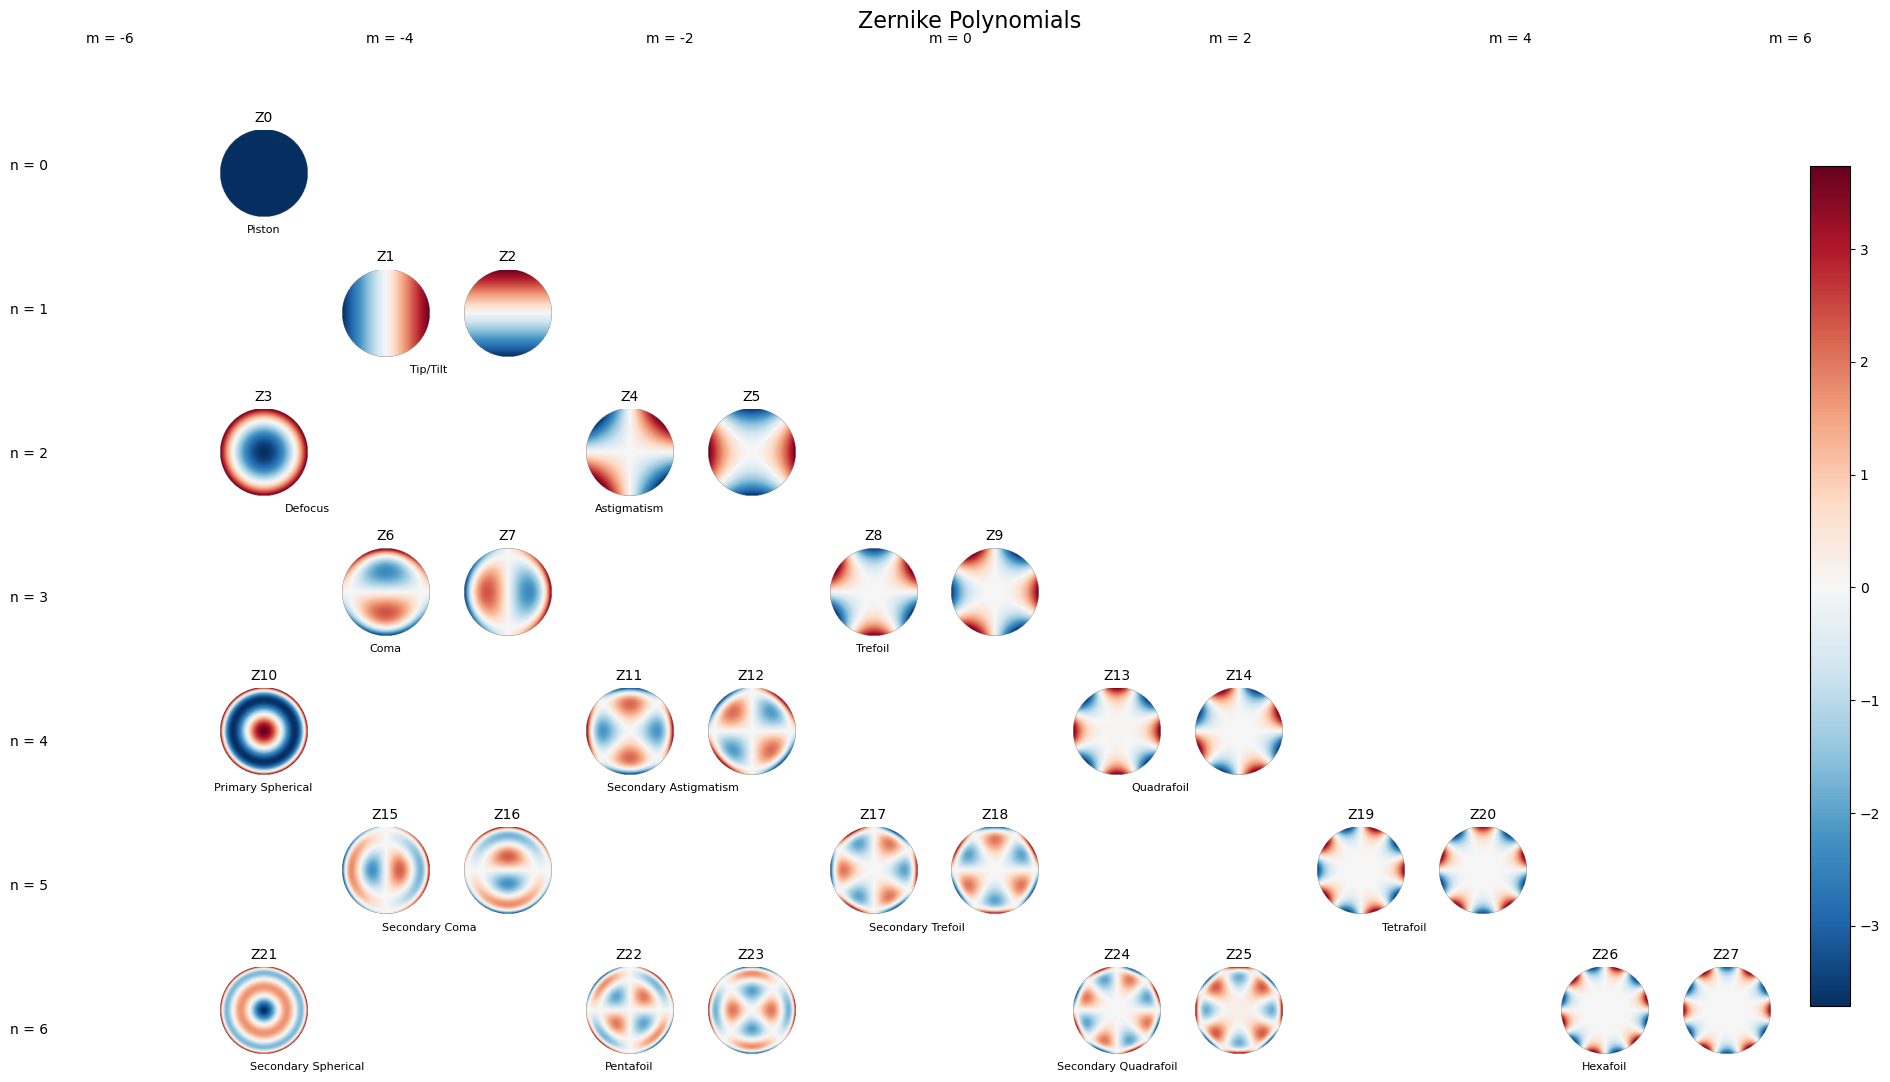

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

def noll_to_zernike(j):
    n = int(np.floor((np.sqrt(8*j+1)-1)/2))
    m = 2*j - n*(n+2)
    return n, m

cart = RZern(6)
L, K = 200, 250
ddx = np.linspace(-1.0, 1.0, K)
ddy = np.linspace(-1.0, 1.0, L)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)

c = np.zeros(cart.nk)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(7, 13, hspace=0.6, wspace=0.4)

plot_positions = [
    (0, 0),
           (1, 1), (1, 2),
    (2, 0),               (2, 3), (2, 4),
           (3, 1), (3, 2),               (3, 5), (3, 6),
    (4, 0),               (4, 3), (4, 4),               (4, 7), (4, 8),
           (5, 1), (5, 2),               (5, 5), (5, 6),               (5, 9), (5, 10),
    (6, 0),               (6, 3), (6, 4),               (6, 7), (6, 8),               (6, 11), (6, 12)
]

zernike_names = [
    "Piston", "Tip/Tilt", None, "Defocus", "Astigmatism", None,
    "Coma", None, "Trefoil", None, "Primary Spherical",
    "Secondary Astigmatism", None, "Quadrafoil", None,
    "Secondary Coma", None, "Secondary Trefoil", None,
    "Tetrafoil", None, "Secondary Spherical", "Pentafoil", None,
    "Secondary Quadrafoil", None, "Hexafoil", None
]

for i in range(28):
    ax = fig.add_subplot(gs[plot_positions[i]])
    c *= 0.0
    c[i] = 1.0
    Phi = cart.eval_grid(c, matrix=True)
    im = ax.imshow(Phi, origin='lower', extent=(-1, 1, -1, 1), cmap='RdBu_r')
    ax.set_title(f'Z{i}', fontsize=10)
    ax.axis('off')
    
    # Add Zernike name labels
    if zernike_names[i]:
        label_x = 0.5
        if i % 2 == 1:  # For odd indices, center the label between two plots
            label_x = 1.0
        ax.text(label_x, -0.15, zernike_names[i], ha='center', va='center', transform=ax.transAxes, fontsize=8, wrap=True)

# Add n, m labels along rows and columns
for i in range(7):
    fig.text(0.02, 0.85 - i*0.12, f'n = {i}', ha='left', va='center', fontsize=10)

for i in range(13):
    if i % 2 == 0:
        m = i - 6
        fig.text(0.07 + i*0.07, 0.95, f'm = {m}', ha='center', va='bottom', fontsize=10)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)

# Add title
fig.suptitle('Zernike Polynomials', fontsize=16, y=0.98)

plt.show()